Install duckdb

In [1]:
import duckdb

Connect to a db instance (it will create one if there is no object created already)

In [2]:
con = duckdb.connect('ecommerce.db')

Create tables in ecommerce.db

In [3]:
con.execute("""
  CREATE OR REPLACE TABLE customers (
    customer_id  INTEGER PRIMARY KEY,
    name         VARCHAR,
    country      VARCHAR,
    signup_date  DATE,
    tier         VARCHAR   -- 'bronze','silver','gold'
  )""")

In [4]:
con.execute("""
  CREATE OR REPLACE TABLE products (
    product_id   INTEGER PRIMARY KEY,
    name         VARCHAR,
    category     VARCHAR,
    price        DECIMAL(10,2),
    stock        INTEGER
  )""")

In [5]:
con.execute("""
  CREATE OR REPLACE TABLE orders (
    order_id     INTEGER PRIMARY KEY,
    customer_id  INTEGER,
    product_id   INTEGER,
    quantity     INTEGER,
    order_date   DATE,
    status       VARCHAR   -- 'completed','returned','pending'
  )""")

Populate the databases with data

In [6]:
con.execute("""
  INSERT INTO customers VALUES
    (1,'Alice Martin','Germany','2022-01-15','gold'),
    (2,'Bob Chen','USA','2022-03-10','silver'),
    (3,'Clara Diaz','Mexico','2022-06-01','bronze'),
    (4,'David Kim','South Korea','2021-11-20','gold'),
    (5,'Emma Wilson','UK','2023-01-05','silver'),
    (6,'Fatima Al-Hassan','UAE','2022-09-14','bronze'),
    (7,'George Papadopoulos','Greece','2021-07-30','gold'),
    (8,'Hana Tanaka','Japan','2023-02-18','silver')""")

In [7]:
con.execute("""
  INSERT INTO products VALUES
    (1,'Laptop Pro 15','Electronics',1299.99,45),
    (2,'Wireless Headphones','Electronics',89.99,200),
    (3,'Running Shoes','Apparel',129.99,150),
    (4,'Coffee Maker','Kitchen',79.99,80),
    (5,'Yoga Mat','Fitness',49.99,300),
    (6,'Smart Watch','Electronics',349.99,60),
    (7,'Backpack','Apparel',69.99,120),
    (8,'Blender','Kitchen',59.99,90),
    (9,'Resistance Bands','Fitness',24.99,500),
    (10,'Mechanical Keyboard','Electronics',149.99,75)""")

In [8]:
con.execute("""
  INSERT INTO orders VALUES
    (1,1,1,1,'2024-01-10','completed'),
    (2,1,2,2,'2024-01-15','completed'),
    (3,2,3,1,'2024-01-20','completed'),
    (4,3,5,3,'2024-02-01','returned'),
    (5,4,6,1,'2024-02-05','completed'),
    (6,2,4,2,'2024-02-10','completed'),
    (7,5,7,1,'2024-02-14','pending'),
    (8,6,9,5,'2024-02-20','completed'),
    (9,7,1,2,'2024-03-01','completed'),
    (10,8,10,1,'2024-03-05','completed'),
    (11,1,6,1,'2024-03-10','completed'),
    (12,4,2,3,'2024-03-12','completed'),
    (13,3,8,1,'2024-03-15','returned'),
    (14,5,5,2,'2024-03-20','completed'),
    (15,2,10,1,'2024-03-25','completed'),
    (16,7,3,1,'2024-04-01','completed'),
    (17,8,4,1,'2024-04-03','completed'),
    (18,6,1,1,'2024-04-10','pending'),
    (19,1,9,10,'2024-04-12','completed'),
    (20,4,7,2,'2024-04-15','completed')""")

In [9]:
print('Dataset ready: customers, products, orders')

Dataset ready: customers, products, orders


------ Install SQL engine from duck db to jupyter notebook ---

In [10]:
pip install jupysql duckdb-engine

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
%reload_ext sql
conn = duckdb.connect('ecommerce.db')
%sql conn --alias duckdb

In [12]:
%sql COPY customers TO 'customers.csv' (HEADER, DELIMITER ',');

Running query in 'duckdb'

Count
8


--------Query a CSV without importing it------------

In [13]:
%sql SELECT name, country, tier FROM 'customers.csv' WHERE country IN ('Germany', 'UK', 'Greece');

Running query in 'duckdb'

name,country,tier
Alice Martin,Germany,gold
Emma Wilson,UK,silver
George Papadopoulos,Greece,gold


In [14]:
%sql SELECT tier, COUNT(*) AS total FROM 'customers.csv' GROUP BY tier ORDER BY total DESC;


Running query in 'duckdb'

tier,total
silver,3
gold,3
bronze,2


-----------------EXERCISES-----------------

Exercise 1:
Calculate total revenue from all completed orders (revenue =  quantity * price)

In [15]:
%%sql
SELECT SUM(o.quantity * p.price) AS total_revenue FROM orders AS o
JOIN products AS p USING (product_id) WHERE  o.status = 'completed';


Running query in 'duckdb'

total_revenue
6464.64


Exercise 2: Find the top 3 best selling products by units sold

In [18]:
%%sql
SELECT p.name, SUM(o.quantity) FROM products p JOIN orders o ON p.product_id = o.product_id
WHERE o.status = 'completed' GROUP BY p.product_id, p.name ORDER BY SUM(o.quantity) DESC LIMIT 3;

Running query in 'duckdb'

name,sum(o.quantity)
Resistance Bands,15
Wireless Headphones,5
Laptop Pro 15,3


Execise 3: Count the number of orders placed each month, sorted chronologically. use DATE_TRUNC('month', order_date)
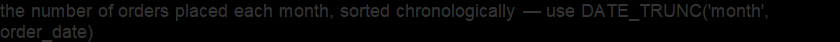

In [2]:
%%sql
SELECT DATE_TRUNC('month', order_date)::DATE AS month,COUNT(*) AS orders_count
FROM orders GROUP BY month ORDER BY month;


CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 2: FROM orders GROUP BY month ORDER BY month;
             ^

Exercise 4: List all individual orders where the total order value (quantity × price) exceeds $500

In [22]:
%%sql
SELECT o.order_id, o.customer_id, o.product_id, o.quantity, o.order_date,p.price * o.quantity as "Total Value" FROM orders o
JOIN products p ON p.product_id = o.product_id WHERE o.status = 'completed' AND
p.price * o.quantity > 500;

Running query in 'duckdb'

order_id,customer_id,product_id,quantity,order_date,Total Value
9,7,1,2,2024-03-01,2599.98
1,1,1,1,2024-01-10,1299.99


----------Export results to Parquet & JSON-------------------

In [23]:
%%sql
%%sql
COPY (
  SELECT o.order_id, c.name AS customer,
         p.name AS product, o.quantity,
         o.quantity * p.price AS total,
         o.order_date
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN products  p ON o.product_id  = p.product_id
  WHERE o.status = 'completed'
) TO 'completed_orders.parquet' (FORMAT PARQUET);


CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 6:   FROM orders o
               ^

In [24]:
%%sql
COPY (
  SELECT o.order_id, c.name AS customer,
         p.name AS product, o.quantity,
         o.quantity * p.price AS total,
         o.order_date
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN products  p ON o.product_id  = p.product_id
  WHERE o.status = 'completed'
) TO 'completed_orders.parquet' (FORMAT PARQUET);


Running query in 'duckdb'

Count
16


In [62]:
%%sql
COPY (
  SELECT o.order_id, c.name AS customer,
         p.name AS product, o.quantity,
         o.quantity * p.price AS total,
         o.order_date
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN products  p ON o.product_id  = p.product_id
  WHERE o.status = 'completed'
) TO 'completed_orders.parquet' (FORMAT PARQUET);

CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 6:   FROM orders o
               ^

In [25]:
%%sql
COPY (
  SELECT o.order_id, c.name AS customer,
         p.name AS product, o.quantity,
         o.quantity * p.price AS total,
         o.order_date
  FROM orders o
  JOIN customers c ON o.customer_id = c.customer_id
  JOIN products  p ON o.product_id  = p.product_id
  WHERE o.status = 'completed'
) TO 'completed_orders.parquet' (FORMAT PARQUET);

Running query in 'duckdb'

Count
16


In [26]:
%sql SELECT COUNT(*) FROM 'completed_orders.parquet';

Running query in 'duckdb'

count_star()
16


In [27]:
%%sql
COPY ( SELECT * FROM 'completed_orders.parquet' )
TO 'completed_orders.json' (FORMAT JSON, ARRAY true);


,Count
0,16


Window functions perform calculations across a set of rows without collapsing them into a single output row. They are essential for rankings, running totals, and peer comparisons.

In [28]:
%%sql
-- Customer rankings by total spend
SELECT c.name,
  ROUND(SUM(o.quantity * p.price), 2) AS total_spend,
  RANK() OVER (ORDER BY SUM(o.quantity * p.price) DESC) AS rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
GROUP BY c.name, c.customer_id;

CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 5: FROM orders o
             ^

In [29]:
%%sql
-- Customer rankings by total spend
SELECT c.name,
  ROUND(SUM(o.quantity * p.price), 2) AS total_spend,
  RANK() OVER (ORDER BY SUM(o.quantity * p.price) DESC) AS rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
GROUP BY c.name, c.customer_id;

Running query in 'duckdb'

name,total_spend,rank
George Papadopoulos,2729.97,1
Alice Martin,2079.86,2
David Kim,759.94,3
Bob Chen,439.96,4
Hana Tanaka,229.98,5
Fatima Al-Hassan,124.95,6
Emma Wilson,99.98,7


In [68]:
%%sql
SELECT c.name,
  ROUND(SUM(o.quantity * p.price), 2) AS total_spend,
  RANK() OVER (ORDER BY SUM(o.quantity * p.price) DESC) AS rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
GROUP BY c.name, c.customer_id;

Running query in 'duckdb'

name,total_spend,rank
George Papadopoulos,2729.97,1
Alice Martin,2079.86,2
David Kim,759.94,3
Bob Chen,439.96,4
Hana Tanaka,229.98,5
Fatima Al-Hassan,124.95,6
Emma Wilson,99.98,7


In [30]:
%%sql
SELECT c.name,
  ROUND(SUM(o.quantity * p.price), 2) AS total_spend,
  RANK() OVER (ORDER BY SUM(o.quantity * p.price) DESC) AS rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
GROUP BY c.name, c.customer_id;

Running query in 'duckdb'

name,total_spend,rank
George Papadopoulos,2729.97,1
Alice Martin,2079.86,2
David Kim,759.94,3
Bob Chen,439.96,4
Hana Tanaka,229.98,5
Fatima Al-Hassan,124.95,6
Emma Wilson,99.98,7


In [31]:
%%sql
-- Running total per customer
SELECT c.name, o.order_date,
  o.quantity * p.price AS order_value,
  ROUND(SUM(o.quantity * p.price) OVER (
    PARTITION BY o.customer_id
    ORDER BY o.order_date
  ), 2) AS running_total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
ORDER BY c.name, o.order_date;

CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 8: FROM orders o
             ^

In [32]:
%%sql
SELECT c.name,
  ROUND(SUM(o.quantity * p.price), 2) AS total_spend,
  RANK() OVER (ORDER BY SUM(o.quantity * p.price) DESC) AS rank
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
GROUP BY c.name, c.customer_id;

Running query in 'duckdb'

name,total_spend,rank
George Papadopoulos,2729.97,1
Alice Martin,2079.86,2
David Kim,759.94,3
Bob Chen,439.96,4
Hana Tanaka,229.98,5
Fatima Al-Hassan,124.95,6
Emma Wilson,99.98,7


In [1]:
%%sql
-- Running total per customer
SELECT c.name, o.order_date,
  o.quantity * p.price AS order_value,
  ROUND(SUM(o.quantity * p.price) OVER (
    PARTITION BY o.customer_id
    ORDER BY o.order_date
  ), 2) AS running_total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
ORDER BY c.name, o.order_date;

CatalogException: Catalog Error: Table with name orders does not exist!
Did you mean "pg_prepared_statements"?

LINE 8: FROM orders o
             ^

In [33]:
%%sql
-- Running total per customer
SELECT c.name, o.order_date,
  o.quantity * p.price AS order_value,
  ROUND(SUM(o.quantity * p.price) OVER (
    PARTITION BY o.customer_id
    ORDER BY o.order_date
  ), 2) AS running_total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
ORDER BY c.name, o.order_date;

Running query in 'duckdb'

name,order_date,order_value,running_total
Alice Martin,2024-01-10,1299.99,1299.99
Alice Martin,2024-01-15,179.98,1479.97
Alice Martin,2024-03-10,349.99,1829.96
Alice Martin,2024-04-12,249.90,2079.86
Bob Chen,2024-01-20,129.99,129.99
Bob Chen,2024-02-10,159.98,289.97
Bob Chen,2024-03-25,149.99,439.96
David Kim,2024-02-05,349.99,349.99
David Kim,2024-03-12,269.97,619.96
David Kim,2024-04-15,139.98,759.94


PIVOT - reshape data for reporting; DuckDB includes native PIVOT and UNPIVOT syntax, no CASE WHEN hacks needed. PIVOT converts row values into column headers, which is ideal for cross-tab reports and dashboards
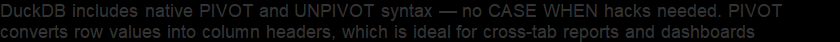

In [32]:
%%sql
--Units sold per category per month
PIVOT (
  SELECT p.category,
         DATE_TRUNC('month', o.order_date)::VARCHAR AS month,
         o.quantity
  FROM orders o
  JOIN products p ON o.product_id = p.product_id
)
ON month
USING SUM(quantity)
GROUP BY category;

Running query in 'duckdb'

category,2024-01-01 00:00:00,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00
Electronics,3,1,8,1
Fitness,None,8,2,10
Kitchen,None,2,1,1
Apparel,1,1,None,3


In [34]:
%%sql
-- Running total per customer
SELECT c.name, o.order_date,
  o.quantity * p.price AS order_value,
  ROUND(SUM(o.quantity * p.price) OVER (
    PARTITION BY o.customer_id
    ORDER BY o.order_date
  ), 2) AS running_total
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN products  p ON o.product_id  = p.product_id
WHERE o.status = 'completed'
ORDER BY c.name, o.order_date;

Running query in 'duckdb'

name,order_date,order_value,running_total
Alice Martin,2024-01-10,1299.99,1299.99
Alice Martin,2024-01-15,179.98,1479.97
Alice Martin,2024-03-10,349.99,1829.96
Alice Martin,2024-04-12,249.90,2079.86
Bob Chen,2024-01-20,129.99,129.99
Bob Chen,2024-02-10,159.98,289.97
Bob Chen,2024-03-25,149.99,439.96
David Kim,2024-02-05,349.99,349.99
David Kim,2024-03-12,269.97,619.96
David Kim,2024-04-15,139.98,759.94


In [33]:
%%sql
-- Order status pivot per customer
PIVOT orders
ON status
USING COUNT(order_id)
GROUP BY customer_id;

Running query in 'duckdb'

customer_id,completed,pending,returned
1,4,0,0
2,3,0,0
3,0,0,2
4,3,0,0
5,1,1,0
6,1,1,0
7,2,0,0
8,2,0,0


CTEs: multi-step analysis; Common Table Expressions (CTEs) let you break a complex query into named, readable steps. This exercise chains multiple CTEs to identify high-value customers who may be at risk of churning.
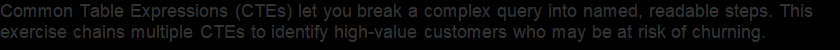
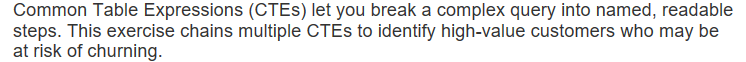

In [ ]:
%%sql

WITH customer_stats AS (
  SELECT o.customer_id,
    COUNT(*) AS order_count,
    SUM(o.quantity * p.price) AS total_spend,
    MAX(o.order_date) AS last_order
  FROM orders o
  JOIN products p ON o.product_id = p.product_id
  WHERE o.status = 'completed'
  GROUP BY o.customer_id
),
segmented AS (
  SELECT *,
    CASE WHEN total_spend > 500 THEN 'high-value'
         ELSE 'regular' END AS segment
  FROM customer_stats
)
SELECT c.name, s.total_spend, s.last_order
FROM segmented s
JOIN customers c ON s.customer_id = c.customer_id
WHERE s.segment = 'high-value'
  AND s.last_order < CURRENT_DATE - INTERVAL '45 days';

